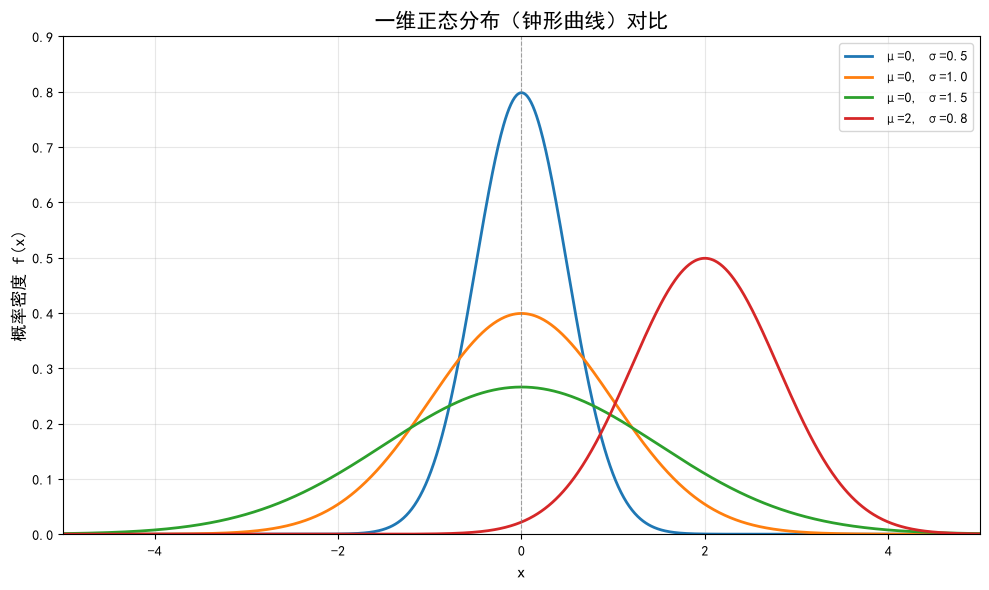

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

# 1. 生成横坐标数据（覆盖大部分概率密度区域）
x = np.linspace(-5, 5, 1000)

# 2. 定义几组不同的正态分布参数 (mu, sigma)
params = [
    (0, 0.5, 'μ=0, σ=0.5'),
    (0, 1.0, 'μ=0, σ=1.0'),
    (0, 1.5, 'μ=0, σ=1.5'),
    (2, 0.8, 'μ=2, σ=0.8')
]

# 3. 创建画布
plt.figure(figsize=(10, 6))

# 4. 绘制每条 PDF 曲线
for mu, sigma, label in params:
    y = norm.pdf(x, mu, sigma)   # 计算概率密度
    plt.plot(x, y, label=label, linewidth=2)

# 5. 添加辅助元素
plt.title('一维正态分布（钟形曲线）对比', fontsize=15)
plt.xlabel('x', fontsize=12)
plt.ylabel('概率密度 f(x)', fontsize=12)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # 参考线
plt.grid(alpha=0.3)
plt.legend()
plt.xlim(-5, 5)
plt.ylim(0, 0.9)

# 6. 显示图形
plt.tight_layout()
plt.show()

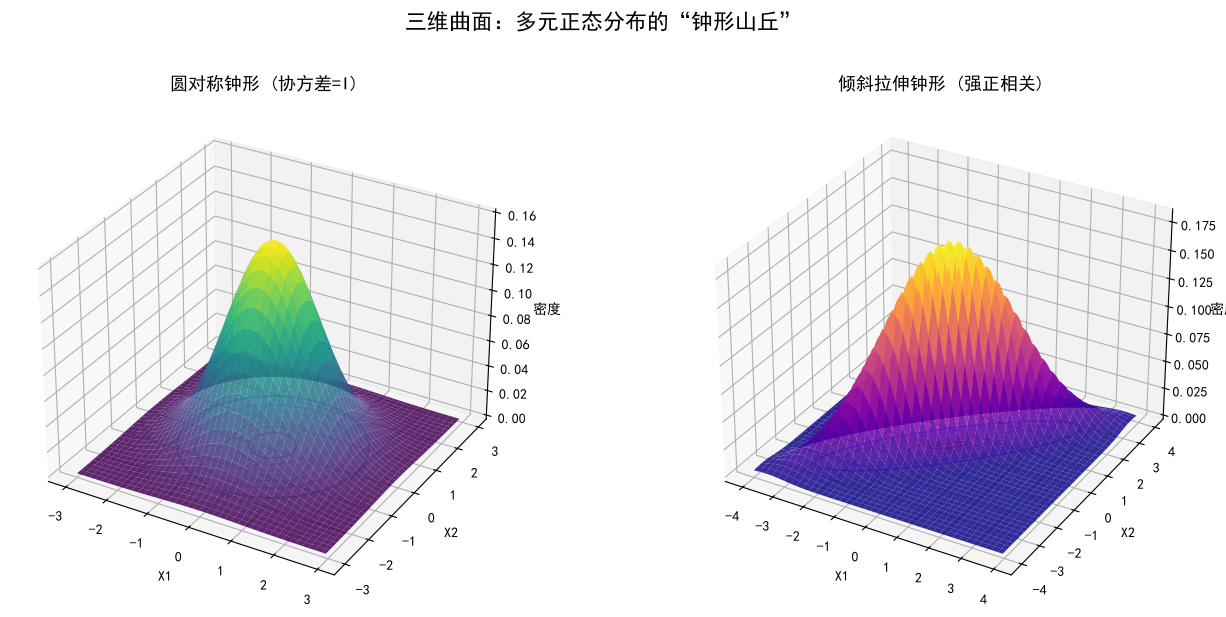

In [3]:
# ================= 2. 三维曲面：展现真正的“高维钟形” =================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# 场景 A：标准圆对称（各向同性）
ax1 = fig.add_subplot(121, projection='3d')
mean_a = [0, 0]
cov_a = [[1, 0], [0, 1]]
x_a, y_a = np.mgrid[-3:3:.05, -3:3:.05]
pos_a = np.dstack((x_a, y_a))
z_a = multivariate_normal(mean_a, cov_a).pdf(pos_a)

ax1.plot_surface(x_a, y_a, z_a, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.contour(x_a, y_a, z_a, zdir='z', offset=0, cmap='coolwarm', alpha=0.6)  # 底部投影
ax1.set_title('圆对称钟形 (协方差=I)', fontsize=13)
ax1.set_xlabel('X1'); ax1.set_ylabel('X2'); ax1.set_zlabel('密度')

# 场景 B：倾斜拉伸（强相关性）
ax2 = fig.add_subplot(122, projection='3d')
mean_b = [0, 0]
cov_b = [[2, 1.8], [1.8, 2]]  # 高度正相关
x_b, y_b = np.mgrid[-4:4:.05, -4:4:.05]
pos_b = np.dstack((x_b, y_b))
z_b = multivariate_normal(mean_b, cov_b).pdf(pos_b)

ax2.plot_surface(x_b, y_b, z_b, cmap='plasma', alpha=0.85, edgecolor='none')
ax2.contour(x_b, y_b, z_b, zdir='z', offset=0, cmap='coolwarm', alpha=0.6)
ax2.set_title('倾斜拉伸钟形 (强正相关)', fontsize=13)
ax2.set_xlabel('X1'); ax2.set_ylabel('X2'); ax2.set_zlabel('密度')

plt.suptitle('三维曲面：多元正态分布的“钟形山丘”', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

离散概率总和: 1.0000


AttributeError: module 'numpy' has no attribute 'trapz'

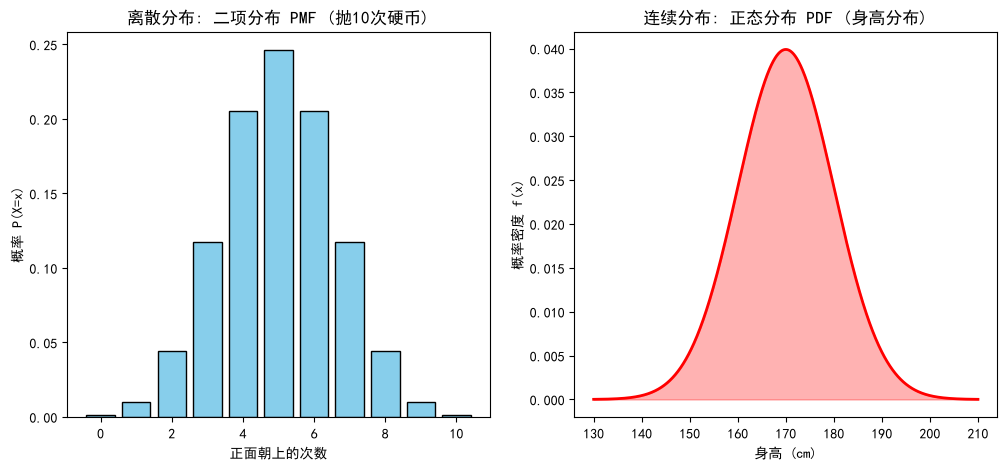

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ==========================================
# 1. 离散分布：二项分布 (抛10次硬币，正面朝上的次数)
# ==========================================
n = 10      # 抛掷次数
p = 0.5     # 正面概率
x_discrete = np.arange(0, n + 1)
# 计算概率质量函数 (PMF)
pmf = stats.binom.pmf(x_discrete, n, p) 

ax1.bar(x_discrete, pmf, color='skyblue', edgecolor='black')
ax1.set_title("离散分布: 二项分布 PMF (抛10次硬币)")
ax1.set_xlabel("正面朝上的次数")
ax1.set_ylabel("概率 P(X=x)")
# 验证铁律：所有柱子高度之和为 1
print(f"离散概率总和: {np.sum(pmf):.4f}") 

# ==========================================
# 2. 连续分布：正态分布 (人类身高分布)
# ==========================================
mu = 170    # 均值 170cm
sigma = 10  # 标准差 10cm
x_continuous = np.linspace(130, 210, 1000)
# 计算概率密度函数 (PDF)
pdf = stats.norm.pdf(x_continuous, mu, sigma)

ax2.plot(x_continuous, pdf, color='red', linewidth=2)
ax2.fill_between(x_continuous, pdf, color='red', alpha=0.3) # 填充面积
ax2.set_title("连续分布: 正态分布 PDF (身高分布)")
ax2.set_xlabel("身高 (cm)")
ax2.set_ylabel("概率密度 f(x)")
# 验证铁律：曲线下总面积为 1
area = np.trapz(pdf, x_continuous)
print(f"连续密度曲线下总面积: {area:.4f}")

plt.tight_layout()
plt.show()

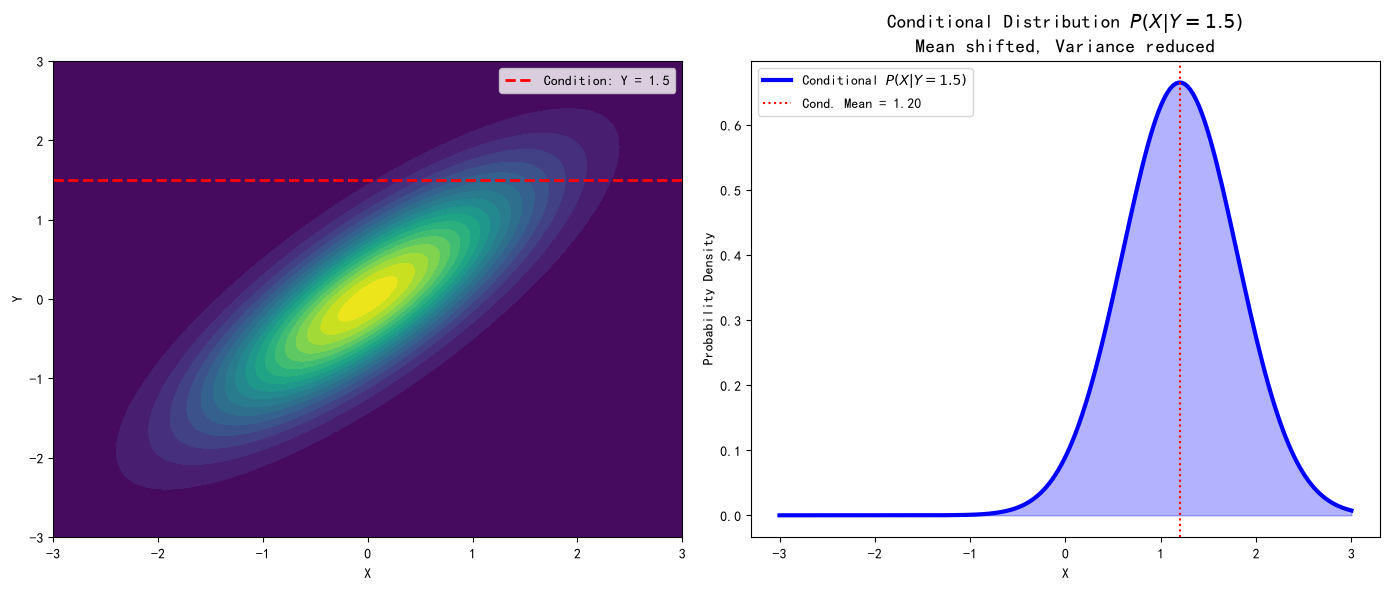

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# 1. 定义二维联合高斯分布
mean = [0, 0]
# 协方差矩阵：X和Y有较强的正相关性 (0.8)
cov = [[1.0, 0.8], 
       [0.8, 1.0]] 
joint_dist = multivariate_normal(mean, cov)

# 2. 生成网格并计算联合 PDF
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = joint_dist.pdf(pos)

# 3. 计算条件分布 (假设我们观察到 Y = 1.5)
y_obs = 1.5
# 根据公式计算条件均值和条件方差
mu_x_given_y = mean[0] + cov[0][1] / cov[1][1] * (y_obs - mean[1])
var_x_given_y = cov[0][0] - (cov[0][1]**2) / cov[1][1]
std_x_given_y = np.sqrt(var_x_given_y)

# 4. 可视化
fig = plt.figure(figsize=(14, 6))

# 左图：二维联合分布的等高线图
ax1 = fig.add_subplot(121)
contour = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
# 画出 Y = 1.5 的“切片”线
ax1.axhline(y=y_obs, color='red', linestyle='--', linewidth=2, label=f'Condition: Y = {y_obs}')
ax1.set_title("Joint Distribution $P(X, Y)$\n(Red line is the slice)", color='white', fontsize=14)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()

# 右图：条件分布 (一维高斯)
ax2 = fig.add_subplot(122)
# 提取切片处的联合概率 (未归一化)
slice_idx = np.argmin(np.abs(y - y_obs))
joint_slice = Z[slice_idx, :]
# 理论上的条件分布 (已归一化)
cond_pdf = norm.pdf(x, mu_x_given_y, std_x_given_y)

ax2.plot(x, cond_pdf, 'b-', linewidth=3, label=f'Conditional $P(X|Y={y_obs})$')
ax2.fill_between(x, cond_pdf, color='blue', alpha=0.3)
ax2.axvline(mu_x_given_y, color='red', linestyle=':', label=f'Cond. Mean = {mu_x_given_y:.2f}')
ax2.set_title(f"Conditional Distribution $P(X | Y={y_obs})$\nMean shifted, Variance reduced", fontsize=14)
ax2.set_xlabel("X")
ax2.set_ylabel("Probability Density")
ax2.legend()

plt.tight_layout()
plt.show()

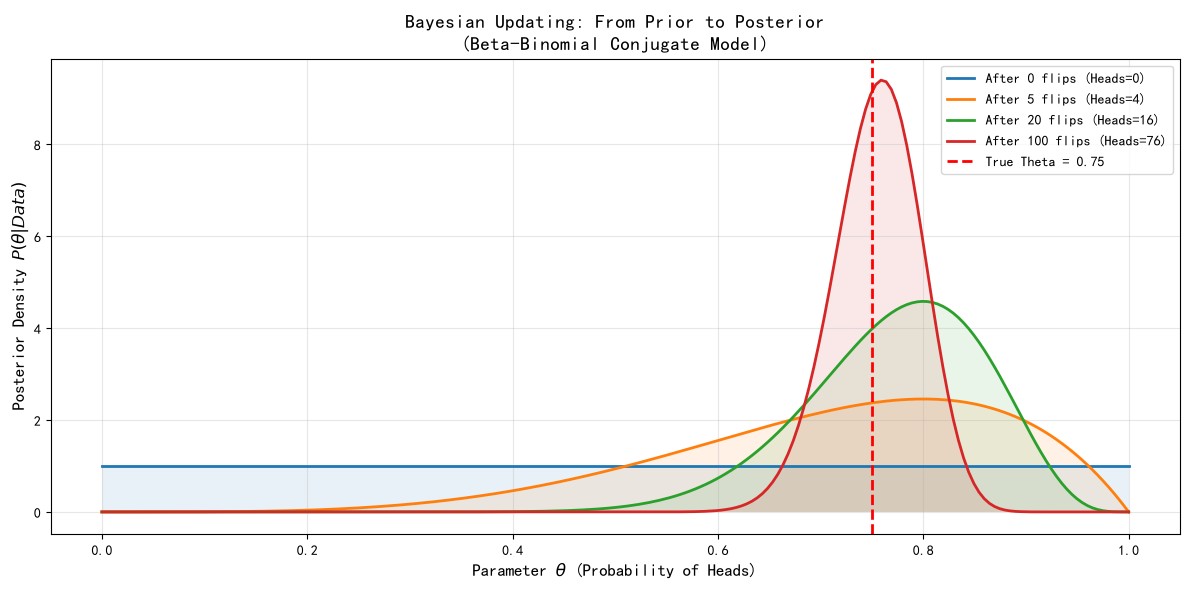

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 1. 设定真实世界的真理（上帝视角，AI不知道）
true_theta = 0.75  # 硬币真实的正面概率是 75%

# 2. 设定先验 (Prior)
# Beta(1, 1) 等价于 [0, 1] 上的均匀分布，代表“我完全不知道，任何概率都有可能”
prior_alpha, prior_beta_param = 1, 1 

# 3. 模拟抛硬币实验 (生成数据)
np.random.seed(42)
num_flips = 100
# 1代表正面，0代表反面
flips = np.random.binomial(1, true_theta, num_flips) 

# 4. 贝叶斯更新过程
# 对于二项分布，Beta分布是其共轭先验。
# 后验的 alpha = 先验alpha + 正面次数
# 后验的 beta = 先验beta + 反面次数
checkpoints = [0, 5, 20, 100] # 我们在这些节点观察后验分布
x = np.linspace(0, 1, 200)

plt.figure(figsize=(12, 6))

for i, n in enumerate(checkpoints):
    # 计算到第 n 次为止的正面和反面次数
    heads = np.sum(flips[:n])
    tails = n - heads
    
    # 计算后验分布参数
    post_alpha = prior_alpha + heads
    post_beta = prior_beta_param + tails
    
    # 计算后验 PDF
    posterior_pdf = beta.pdf(x, post_alpha, post_beta)
    
    # 绘图
    plt.plot(x, posterior_pdf, label=f'After {n} flips (Heads={heads})', linewidth=2)
    plt.fill_between(x, posterior_pdf, alpha=0.1)

# 画出真实的真理线
plt.axvline(true_theta, color='red', linestyle='--', linewidth=2, label=f'True Theta = {true_theta}')

plt.title("Bayesian Updating: From Prior to Posterior\n(Beta-Binomial Conjugate Model)", fontsize=14)
plt.xlabel("Parameter $\\theta$ (Probability of Heads)", fontsize=12)
plt.ylabel("Posterior Density $P(\\theta | Data)$", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

--- 拟合结果 ---
真实参数: mu = 50, sigma = 12
拟合参数: mu = 52.86, sigma = 16.54


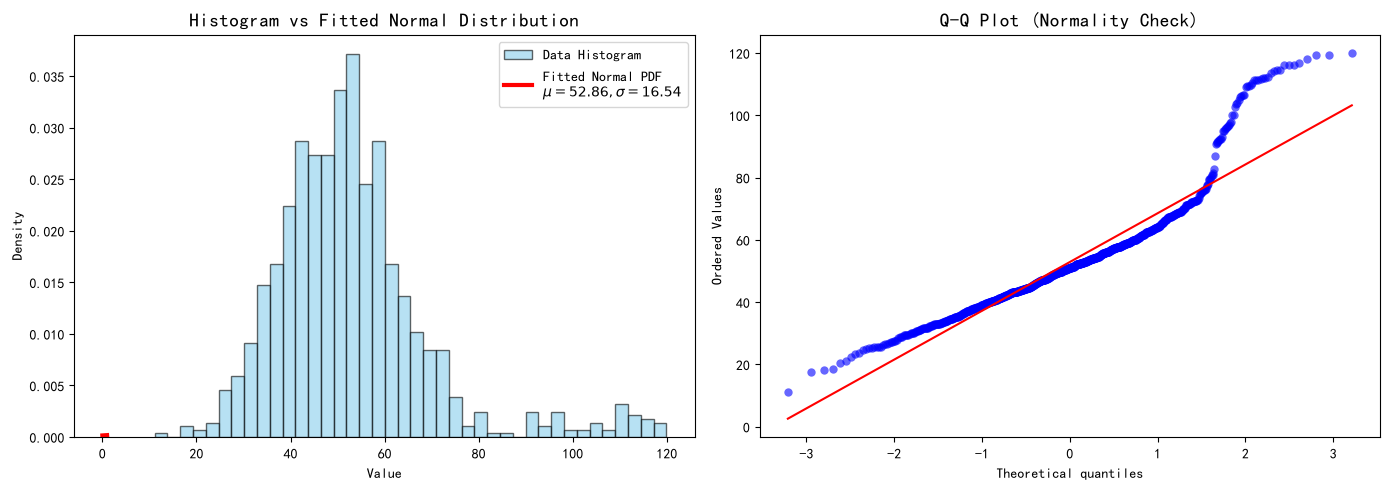

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. 生成模拟数据 (Ground Truth)
# ==========================================
np.random.seed(42)
true_mu, true_sigma = 50, 12
# 生成 1000 个正态分布数据点，并混入 50 个极端异常值（模拟真实世界的脏数据）
data_clean = np.random.normal(loc=true_mu, scale=true_sigma, size=1000)
outliers = np.random.uniform(90, 120, size=50) 
data = np.concatenate([data_clean, outliers])

# ==========================================
# 2. 拟合正态分布 (Maximum Likelihood Estimation)
# ==========================================
# stats.norm.fit 会自动返回最大似然估计的 mu 和 sigma
fitted_mu, fitted_sigma = stats.norm.fit(data)

print(f"--- 拟合结果 ---")
print(f"真实参数: mu = {true_mu}, sigma = {true_sigma}")
print(f"拟合参数: mu = {fitted_mu:.2f}, sigma = {fitted_sigma:.2f}")

# ==========================================
# 3. 可视化与拟合优度检验
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：直方图 + 拟合的 PDF 曲线
count, bins, ignored = ax1.hist(data, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
# 使用拟合出的参数计算理论 PDF
p = stats.norm.pdf(x, fitted_mu, fitted_sigma) 
ax1.plot(x, p, 'r-', linewidth=3, label=f'Fitted Normal PDF\n$\\mu={fitted_mu:.2f}, \\sigma={fitted_sigma:.2f}$')
ax1.set_title("Histogram vs Fitted Normal Distribution", fontsize=14)
ax1.set_xlabel("Value")
ax1.set_ylabel("Density")
ax1.legend()

# 右图：Q-Q 图 (Quantile-Quantile Plot) - 检验正态性的黄金标准
# 如果数据完美服从正态分布，所有的点都会落在红色的对角线上
stats.probplot(data, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot (Normality Check)", fontsize=14)
ax2.get_lines()[0].set(markerfacecolor='blue', markeredgecolor='none', alpha=0.6) # 美化散点

plt.tight_layout()
plt.show()

--- 抽样验证 (N=10000) ---
真实参数: mu = 50.0, sigma = 12.0
样本均值: 49.8867 (逼近 mu)
样本标准差: 12.0270 (逼近 sigma)


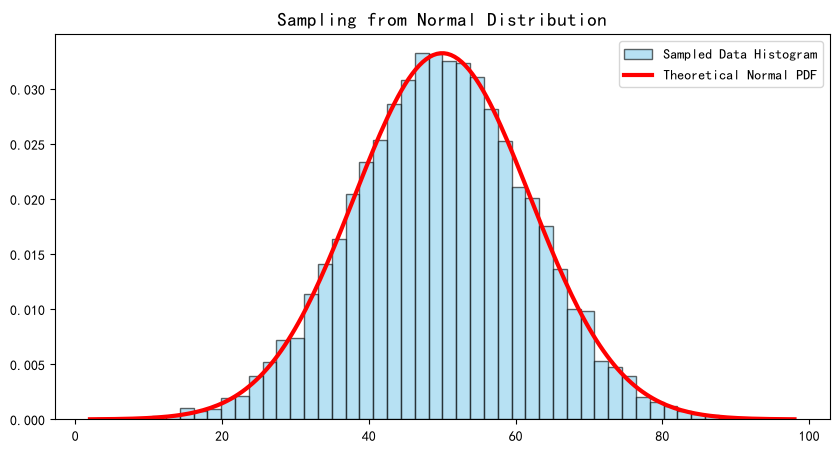

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 假设这是我们上一轮拟合出的正态分布参数
fitted_mu = 50.0
fitted_sigma = 12.0

# ==========================================
# 方法 A：使用 NumPy (最常用、最快)
# ==========================================
# 生成 10000 个样本
samples_numpy = np.random.normal(loc=fitted_mu, scale=fitted_sigma, size=10000)

# ==========================================
# 方法 B：使用 SciPy (面向对象，适合复杂统计)
# ==========================================
# 先“冻结”一个分布对象，然后调用 rvs (random variates) 方法
dist = stats.norm(loc=fitted_mu, scale=fitted_sigma)
samples_scipy = dist.rvs(size=10000)

# ==========================================
# 验证大数定律：样本统计量 vs 真实参数
# ==========================================
print(f"--- 抽样验证 (N=10000) ---")
print(f"真实参数: mu = {fitted_mu}, sigma = {fitted_sigma}")
print(f"样本均值: {np.mean(samples_numpy):.4f} (逼近 mu)")
print(f"样本标准差: {np.std(samples_numpy):.4f} (逼近 sigma)")

# 可视化：核密度估计 (KDE) 对比理论 PDF
plt.figure(figsize=(10, 5))
count, bins, ignored = plt.hist(samples_numpy, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sampled Data Histogram')
x = np.linspace(fitted_mu - 4*fitted_sigma, fitted_mu + 4*fitted_sigma, 200)
plt.plot(x, dist.pdf(x), 'r-', linewidth=3, label='Theoretical Normal PDF')
plt.title("Sampling from Normal Distribution", fontsize=14)
plt.legend()
plt.show()

findfont: Failed to find font weight bold, now using 400.


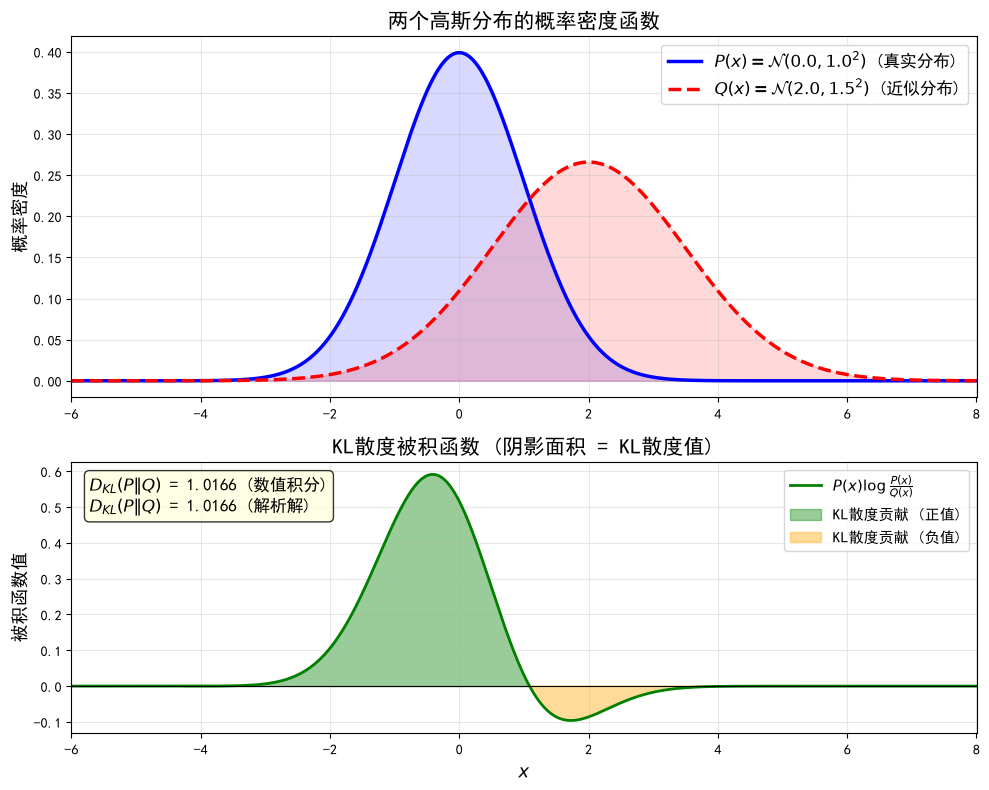

KL(P||Q) 数值积分: 1.016576
KL(P||Q) 解析解:   1.016576


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import trapezoid

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ===== 定义两个高斯分布 =====
mu_p, sigma_p = 0.0, 1.0    # 真实分布 P
mu_q, sigma_q = 2.0, 1.5    # 近似分布 Q

P = norm(mu_p, sigma_p)
Q = norm(mu_q, sigma_q)

# 生成x轴数据
x = np.linspace(-6, 8, 2000)
p_x = P.pdf(x)
q_x = Q.pdf(x)

# ===== 计算KL散度被积函数 =====
epsilon = 1e-10  # 防止 log(0)
p_safe = np.clip(p_x, epsilon, None)
q_safe = np.clip(q_x, epsilon, None)

# KL(P||Q) 的被积函数
kl_integrand = p_safe * np.log(p_safe / q_safe)
kl_integrand = np.where(p_x > epsilon, kl_integrand, 0)  # P(x)=0 时贡献为0

# 数值积分
kl_div = trapezoid(kl_integrand, x)

# 高斯分布KL散度的解析解（用于验证）
kl_analytical = (np.log(sigma_q / sigma_p) + 
                 (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5)

# ===== 可视化 =====
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1.5]})

# 子图1：概率密度函数
ax1 = axes[0]
ax1.plot(x, p_x, 'b-', linewidth=2.5, label=f'$P(x) = \mathcal{{N}}({mu_p}, {sigma_p}^2)$ (真实分布)')
ax1.plot(x, q_x, 'r--', linewidth=2.5, label=f'$Q(x) = \mathcal{{N}}({mu_q}, {sigma_q}^2)$ (近似分布)')
ax1.fill_between(x, p_x, alpha=0.15, color='blue')
ax1.fill_between(x, q_x, alpha=0.15, color='red')
ax1.set_ylabel('概率密度', fontsize=13)
ax1.set_title('两个高斯分布的概率密度函数', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-6, 8)

# 子图2：KL散度被积函数
ax2 = axes[1]
ax2.plot(x, kl_integrand, 'g-', linewidth=2, label=r'$P(x) \log \frac{P(x)}{Q(x)}$')
ax2.fill_between(x, kl_integrand, where=(kl_integrand > 0), 
                 alpha=0.4, color='green', label=f'KL散度贡献 (正值)')
ax2.fill_between(x, kl_integrand, where=(kl_integrand < 0), 
                 alpha=0.4, color='orange', label='KL散度贡献 (负值)')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# 标注KL散度值
ax2.text(0.02, 0.95, 
         f'$D_{{KL}}(P \\| Q)$ = {kl_div:.4f} (数值积分)\n'
         f'$D_{{KL}}(P \\| Q)$ = {kl_analytical:.4f} (解析解)',
         transform=ax2.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax2.set_xlabel('$x$', fontsize=13)
ax2.set_ylabel('被积函数值', fontsize=13)
ax2.set_title('KL散度被积函数 (阴影面积 = KL散度值)', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-6, 8)

plt.tight_layout()
plt.savefig('kl_divergence_basic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"KL(P||Q) 数值积分: {kl_div:.6f}")
print(f"KL(P||Q) 解析解:   {kl_analytical:.6f}")

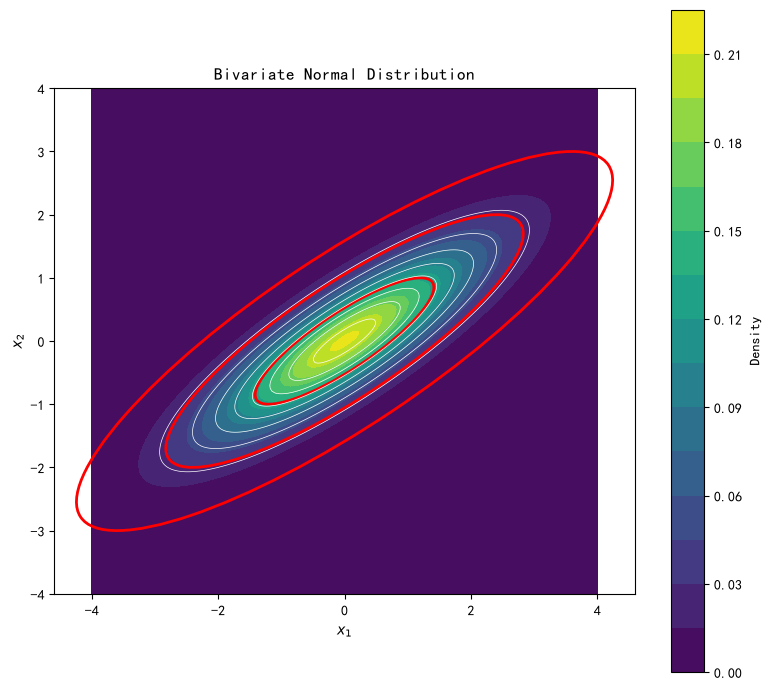

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def multivariate_normal_pdf(x, mu, Sigma):
    """
    多元正态分布概率密度函数
    
    参数:
        x: (N, n) 数据点
        mu: (n,) 均值向量
        Sigma: (n, n) 协方差矩阵
    返回:
        pdf: (N,) 每个点的概率密度
    """
    n = len(mu)
    diff = x - mu  # (N, n)
    Sigma_inv = np.linalg.inv(Sigma)
    det_Sigma = np.linalg.det(Sigma)
    
    # 马氏距离的平方
    mahal = np.sum(diff @ Sigma_inv * diff, axis=1)  # (N,)
    
    # 归一化系数
    norm_const = 1.0 / ((2 * np.pi) ** (n / 2) * det_Sigma ** 0.5)
    
    return norm_const * np.exp(-0.5 * mahal)


# ---- 可视化二维情形 ----
mu = np.array([0, 0])
Sigma = np.array([[2.0, 1.2],
                   [1.2, 1.0]])

# 生成网格
x1 = np.linspace(-4, 4, 200)
x2 = np.linspace(-4, 4, 200)
X1, X2 = np.meshgrid(x1, x2)
X = np.column_stack([X1.ravel(), X2.ravel()])

# 计算PDF
pdf = multivariate_normal_pdf(X, mu, Sigma)
Z = pdf.reshape(X1.shape)

# 绘图
fig, ax = plt.subplots(figsize=(8, 7))
ax.contourf(X1, X2, Z, levels=20, cmap='viridis')
ax.contour(X1, X2, Z, levels=8, colors='white', linewidths=0.5)

# 绘制协方差椭球
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
order = eigenvalues.argsort()[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

for n_std in [1, 2, 3]:
    ell = Ellipse(xy=mu, width=2*n_std*np.sqrt(eigenvalues[0]),
                  height=2*n_std*np.sqrt(eigenvalues[1]),
                  angle=angle, fill=False, color='red', linewidth=2)
    ax.add_patch(ell)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Bivariate Normal Distribution')
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], label='Density')
plt.tight_layout()
plt.show()

C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_37840\3069139878.py:66: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_37840\3069139878.py:66: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
findfont: Failed to find font weight bold, now using 400.
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_37840\3069139878.py:67: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.savefig('normal_fit_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_37840\3069139878.py:67: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('normal_fit_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\yuhao.bian\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIG

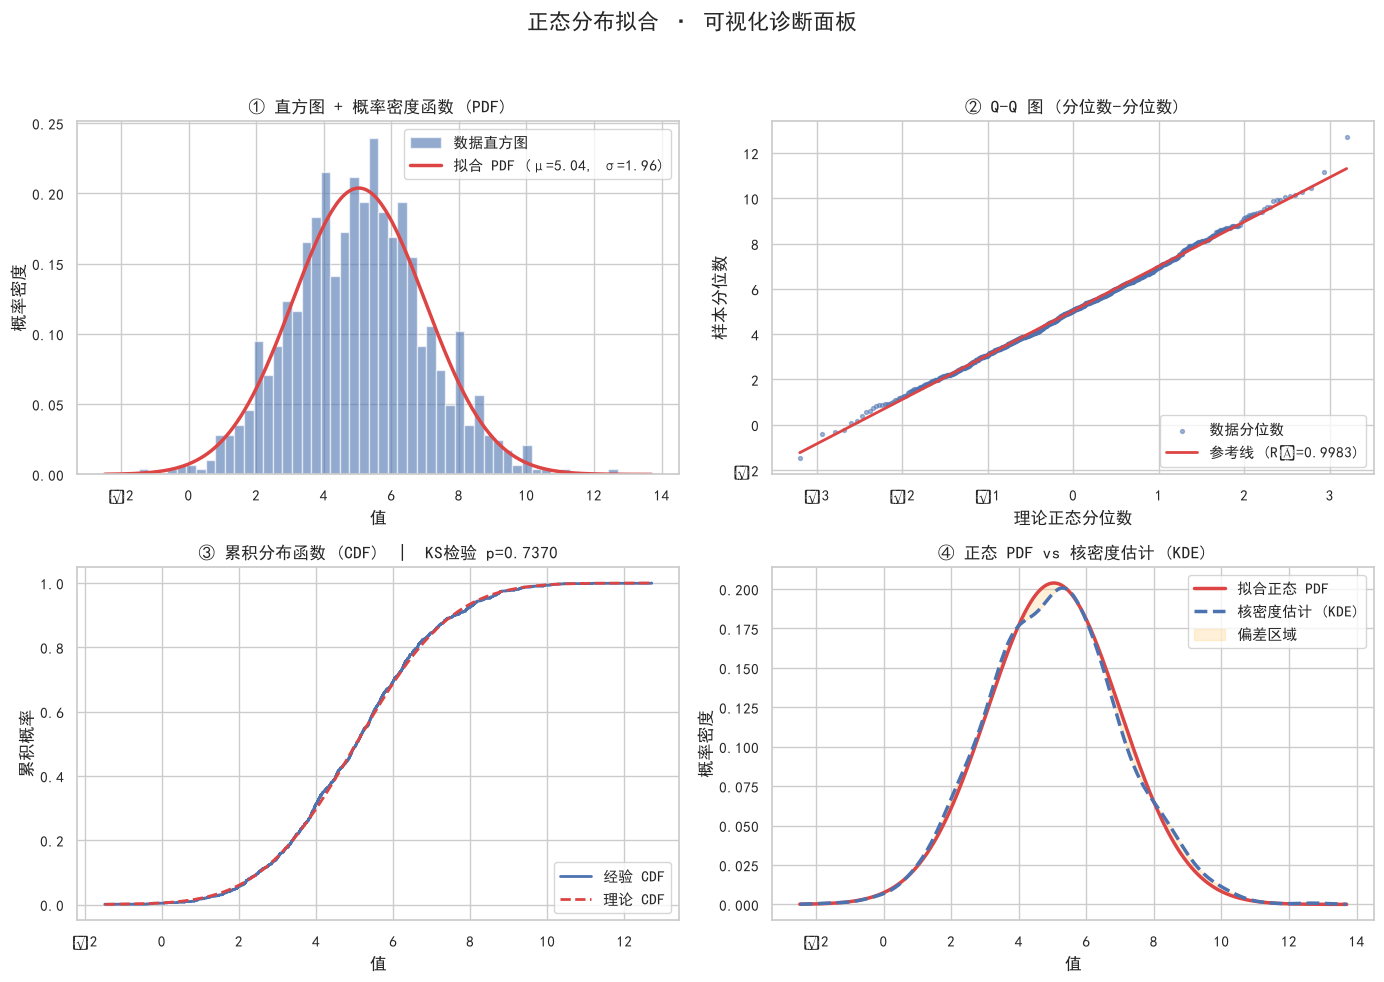

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# ========== 数据准备 ==========
np.random.seed(42)
data = np.random.normal(loc=5, scale=2, size=1000)
mu, sigma = stats.norm.fit(data)

# ========== 绘图设置 ==========
sns.set_theme(style="whitegrid", font="SimHei")  # 中文字体支持
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('正态分布拟合 · 可视化诊断面板', fontsize=16, fontweight='bold', y=0.98)

# 颜色主题
C_DATA   = '#4C72B0'   # 数据
C_FIT    = '#DD4444'   # 拟合曲线
C_CI     = '#AAAAAA'   # 置信带
x_range  = np.linspace(data.min() - 1, data.max() + 1, 500)

# ========== 子图 1：直方图 + PDF ==========
ax1 = axes[0, 0]
ax1.hist(data, bins=50, density=True, alpha=0.6, color=C_DATA, edgecolor='white', label='数据直方图')
pdf = stats.norm.pdf(x_range, mu, sigma)
ax1.plot(x_range, pdf, color=C_FIT, lw=2.5, label=f'拟合 PDF (μ={mu:.2f}, σ={sigma:.2f})')
ax1.set_title('① 直方图 + 概率密度函数 (PDF)', fontsize=12)
ax1.set_xlabel('值')
ax1.set_ylabel('概率密度')
ax1.legend(loc='upper right')

# ========== 子图 2：Q-Q 图 ==========
ax2 = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm', fit=True)
ax2.scatter(osm, osr, s=8, alpha=0.5, color=C_DATA, label='数据分位数')
ax2.plot(osm, intercept + slope * osm, color=C_FIT, lw=2, label=f'参考线 (R²={r**2:.4f})')
ax2.set_title('② Q-Q 图 (分位数-分位数)', fontsize=12)
ax2.set_xlabel('理论正态分位数')
ax2.set_ylabel('样本分位数')
ax2.legend(loc='lower right')

# ========== 子图 3：经验 CDF vs 理论 CDF ==========
ax3 = axes[1, 0]
sorted_data = np.sort(data)
emp_cdf = np.arange(1, len(data) + 1) / len(data)
theo_cdf = stats.norm.cdf(sorted_data, mu, sigma)
ax3.step(sorted_data, emp_cdf, color=C_DATA, lw=2, where='post', label='经验 CDF')
ax3.plot(sorted_data, theo_cdf, color=C_FIT, lw=2, ls='--', label='理论 CDF')
ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu, sigma))
ax3.set_title(f'③ 累积分布函数 (CDF)  |  KS检验 p={ks_p:.4f}', fontsize=12)
ax3.set_xlabel('值')
ax3.set_ylabel('累积概率')
ax3.legend(loc='lower right')

# ========== 子图 4：KDE vs 正态 PDF（残差分析）==========
ax4 = axes[1, 1]
kde = stats.gaussian_kde(data)
ax4.plot(x_range, pdf, color=C_FIT, lw=2.5, label='拟合正态 PDF')
ax4.plot(x_range, kde(x_range), color=C_DATA, lw=2.5, ls='--', label='核密度估计 (KDE)')
ax4.fill_between(x_range, pdf, kde(x_range), alpha=0.15, color='orange', label='偏差区域')
ax4.set_title('④ 正态 PDF vs 核密度估计 (KDE)', fontsize=12)
ax4.set_xlabel('值')
ax4.set_ylabel('概率密度')
ax4.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('normal_fit_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()